## 載入所需套件

In [1]:
# Phase 1: Environment Setup
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import folium
import numpy as np
import os
from dotenv import load_dotenv
from urllib.parse import quote
import json
import rioxarray
from rasterstats import zonal_stats
# Load environment variables
load_dotenv('../.env')

# Check versions
print(f'geopandas {gpd.__version__} ✓')
print(f'pandas {pd.__version__} ✓')
print('All imports OK — ARIA system ready!')

geopandas 1.1.3 ✓
pandas 2.3.3 ✓
All imports OK — ARIA system ready!


# 載入國土測繪中心鄉鎮市區界

In [2]:
# 1. 設定 TGOS 資料來源網址
TGOS_BASE = 'https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/'
# 使用 quote 處理中文字元，避免網址解析錯誤
url = TGOS_BASE + quote('鄉(鎮、市、區)界線1140318.zip')
# 2. 讀取圖資 (指定 layer)
print("正在從 TGOS 載入圖資...")
townships = gpd.read_file(url, layer='TOWN_MOI_1140318')

# 3. 轉換座標系統至 EPSG:3826 (TWD97 121分帶)
townships = townships.to_crs(epsg=3826)

# 4. 印出檢查資訊
print(f"資料形狀 (Shape): {townships.shape}")
print(f"目前座標系統 (CRS): {townships.crs}")
display(townships.head(2))

正在從 TGOS 載入圖資...
資料形狀 (Shape): (368, 8)
目前座標系統 (CRS): EPSG:3826


,TOWNID,TOWNCODE,COUNTYNAME,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE,geometry
0,V02,10014020,臺東縣,成功鎮,Chenggong Township,V,10014,"POLYGON ((286994.568 2569686.978, 287066.318 2..."
1,T21,10013210,屏東縣,佳冬鄉,Jiadong Township,T,10013,"POLYGON ((203528.677 2484633.419, 203536.121 2..."


# 篩選出花蓮縣

In [3]:
# 1. 篩選出花蓮縣的鄉鎮，並確保座標系統為 EPSG:3826 (公尺單位)
hualien_towns = townships[townships['COUNTYNAME'] == '花蓮縣'].to_crs(epsg=3826).copy()
hualien_towns.head(2)

,TOWNID,TOWNCODE,COUNTYNAME,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE,geometry
140,U02,10015070,花蓮縣,光復鄉,Guangfu Township,U,10015,"POLYGON ((302480.788 2623319.278, 302532.989 2..."
141,U09,10015090,花蓮縣,瑞穗鄉,Ruisui Township,U,10015,"POLYGON ((287427.624 2610086.936, 287434.875 2..."


# 載入河川資料

In [4]:
# Phase 2: Load River Data from Local File
# 載入水利署河川面圖資，檢查坐標系統與幾何類型。

print('Loading river polygons from local file...')
rivers = gpd.read_file('../data/riverpoly/riverpoly.shp')

print(f'CRS: {rivers.crs}')
print(f'Geometry type: {rivers.geom_type.unique()}')
rivers.head(2)

Loading river polygons from local file...
CRS: EPSG:3826
Geometry type: ['Polygon' 'MultiPolygon']


,RIVER_NAME,RIVER_TYPE,RIVER_CODE,RIVER_FROM,geometry
0,基隆河,1,114030110.0,淡水河,"POLYGON ((329700.702 2778440.466, 329718.3 277..."
1,田寮河,5,NaN,None,"POLYGON ((330452.047 2778680.465, 330452.544 2..."


## 裁切目標河川

正在裁切花蓮縣河川資料...


C:\Users\Nitro\AppData\Local\Temp\ipykernel_12340\2732566996.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hualien_boundary = hualien_towns.geometry.unary_union


原始河川數量: 13262
裁切後花蓮河川數量: 651


<Axes: >

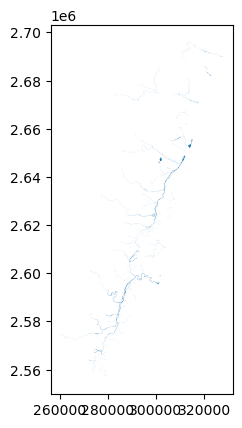

In [5]:
# 1. 確保河川資料也是 EPSG:3826 (與花蓮鄉鎮資料一致)
if rivers.crs != "EPSG:3826":
    print("正在轉換河川資料座標系統...")
    rivers = rivers.to_crs(epsg=3826)

# 2. 將花蓮縣所有鄉鎮合併成一個完整的縣市範圍多邊形
# unary_union 會把所有鄉鎮的多邊形合併成一個大的幾何物件
hualien_boundary = hualien_towns.geometry.unary_union

# 3. 使用 clip 進行裁切
# 這會保留河川在花蓮縣境內的片段，並切掉超出縣界的部份
print("正在裁切花蓮縣河川資料...")
hualien_rivers = gpd.clip(rivers, hualien_boundary)

# 4. 檢查結果
print(f"原始河川數量: {len(rivers)}")
print(f"裁切後花蓮河川數量: {len(hualien_rivers)}")

# 視覺化檢查 (選用)
hualien_rivers.plot()

# 載入清理後的消防署避難收容所

In [6]:
# Phase 3: Load and Use Cleaned Shelter Data
# 直接讀取已清理的避難收容所資料，只使用有效座標的記錄

print('Loading cleaned shelter data...')
shelters_csv_path = '../data/避難收容處所_清理後.csv'

if os.path.exists(shelters_csv_path):
    shelters_csv = pd.read_csv(shelters_csv_path, encoding='utf-8-sig')
    print(f'原始避難收容處所筆數： {len(shelters_csv)} ')
    
    # 只取座標有效性為"有效"的記錄
    if '座標有效性' in shelters_csv.columns:
        valid_shelters = shelters_csv[shelters_csv['座標有效性'] == '有效'].copy()
        print(f'清理後避難收容處所筆數： {len(valid_shelters)}')
        print(f'清理共 {len(shelters_csv) - len(valid_shelters)} 筆座標異常資料')
    else:
        print('Warning: "座標有效性" column not found, using all records')
        valid_shelters = shelters_csv.copy()
else:
    print(f'Warning: {shelters_csv_path} not found')

print(f'\n=== 清理後避難所數據 ===')
print(f'總有效避難收容處: {len(valid_shelters)}')
print(f'總有效收容人數: {valid_shelters["預計收容人數"].sum():,}')

# Convert to GeoDataFrame
shelters = gpd.GeoDataFrame(
    valid_shelters,
    geometry=gpd.points_from_xy(valid_shelters['經度'], valid_shelters['緯度']),
    crs='EPSG:4326'
)
# Convert to EPSG:3826 for analysis
shelters_3826 = shelters.to_crs(epsg=3826)
print(f'\n轉換後坐標系統:\n{shelters_3826.crs}')

shelters_3826.head(1)

Loading cleaned shelter data...
原始避難收容處所筆數： 5973 
清理後避難收容處所筆數： 5790
清理共 183 筆座標異常資料

=== 清理後避難所數據 ===
總有效避難收容處: 5790
總有效收容人數: 2,243,097

轉換後坐標系統:
EPSG:3826


,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,管理人姓名,管理人電話,室內,室外,適合避難弱者安置,座標有效性,座標問題,座標系統,is_indoor,geometry
1,2,金門縣烈嶼鄉,林湖村,東林24號,118.248571,24.428328,金門縣烈嶼鄉林湖村辦公處,林湖村,30,"水災,震災,土石流,海嘯",林妙玲,082-364503,是,否,是,有效,NaN,EPSG:4326,True,POINT (-29071.526 2705233.104)


# 取花蓮縣區域

In [7]:
#取花蓮縣
hualien_shelters = shelters_3826[shelters_3826['縣市及鄉鎮市區'].str[:3] == '花蓮縣']
hualien_shelters.head(2)


,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,管理人姓名,管理人電話,室內,室外,適合避難弱者安置,座標有效性,座標問題,座標系統,is_indoor,geometry
45,46,花蓮縣秀林鄉,和平村,和平112號,121.748879,24.308073,和平國小,和中部落,250,"水災,土石流",蔡金郎,03-868113,是,否,否,有效,NaN,EPSG:4326,True,POINT (326011.111 2689346.508)
1305,1306,花蓮縣富里鄉,豐南村,豐南7鄰12-3號,121.268600,23.143000,豐南社區活動中心,豐南村,50,"水災,震災,土石流,海嘯",黃瓊瑤,03-8831820,是,否,是,有效,NaN,EPSG:4326,True,POINT (277505.779 2560143.417)


# 載入tif檔案，內政部 20m DEM(花蓮縣)

In [8]:
import os
# 1. 設定檔案路徑 (請根據你的 Drive 資料夾結構微調)
# 定義兩個備選路徑
drive_path = '/content/drive/MyDrive/GIS_data/dem_20m_hualien.tif'
local_path = '../data/dem_20m_hualien.tif'

# 2. 判斷路徑並讀取檔案
if os.path.exists(drive_path):
    dem_path = drive_path
elif os.path.exists(local_path):
    dem_path = local_path

dem = rioxarray.open_rasterio(dem_path, masked=True)
# 將 CRS 標註為標準的 EPSG:3826
# inplace=True 代表直接修改原本的 dem 變數
# dem.rio.write_crs("EPSG:3826", inplace=True)

# 3. 提取並列印 Metadata
print("=== DEM Metadata 檢查結果 ===")
print(f"1. 數據形狀 (Bands, Y, X): {dem.shape}")
print(f"2. 座標系統 (CRS): {dem.rio.crs}")
print(f"3. 仿射轉換 (Transform):\n{dem.rio.transform()}")
print(f"4. 空間範圍 (Bounds): {dem.rio.bounds()}")

# 計算數值統計
# 使用 .values 轉換為 numpy 陣列計算，速度較快且處理 NaN
min_val = np.nanmin(dem.values)
max_val = np.nanmax(dem.values)
total_pixels = dem.size

print(f"5. 高程範圍 (Min/Max): {min_val:.2f} ~ {max_val:.2f} m")
print(f"6. 總像素量: {total_pixels:,} pixels")

=== DEM Metadata 檢查結果 ===
1. 數據形狀 (Bands, Y, X): (1, 7054, 3997)
2. 座標系統 (CRS): PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
3. 仿射轉換 (Transform):
| 20.00, 0.00, 248630.00|
| 0.00,-20.00, 2696210.00|
| 0.00, 0.00, 1.00|
4. 空間範圍 (Bounds): (248630.0, 2555130.0, 328570.0, 2696210.0)
5. 高程範圍 (Min/Max): -3.02 ~ 3824.30 m
6. 總像素量: 28,194,838 pixels


## 轉換slope

In [9]:
import numpy as np
dy, dx = np.gradient(dem.values[0], 20)  # 20m resolution
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

## 讀取風險判定門檻閾值

In [10]:
# 讀環境變數
from dotenv import load_dotenv
import os
load_dotenv('../.env')
SLOPE_THRESHOLD = float(os.getenv('SLOPE_THRESHOLD'))
ELEVATION_LOW = float(os.getenv('ELEVATION_LOW'))
TARGET_COUNTY = os.getenv('TARGET_COUNTY')

print(f"系統啟動：目標區域 - {TARGET_COUNTY}")
print(f"風險門檻：坡度 > {SLOPE_THRESHOLD}°, 低海拔 < {ELEVATION_LOW}m")

系統啟動：目標區域 - 花蓮縣
風險門檻：坡度 > 30.0°, 低海拔 < 50.0m


# 讀取風險判定-河川buffer資料

In [11]:
buffer_high = float(os.getenv('BUFFER_HIGH'))
buffer_med = float(os.getenv('BUFFER_MED'))
# Create buffers (rivers already in EPSG:3826)
buffer_high_geom = hualien_rivers.buffer(buffer_high)
buffer_med_geom = hualien_rivers.buffer(buffer_med)

# Create GeoDataFrames for buffers
buffer_high_gdf = gpd.GeoDataFrame(
    {'risk_level': ['high'] * len(buffer_high_geom), 'buffer_m': [buffer_high] * len(buffer_high_geom)},
    geometry=buffer_high_geom,
    crs='EPSG:3826'
)

buffer_med_gdf = gpd.GeoDataFrame(
    {'risk_level': ['medium'] * len(buffer_med_geom), 'buffer_m': [buffer_med] * len(buffer_med_geom)},
    geometry=buffer_med_geom,
    crs='EPSG:3826'
)
# buffer_high_geom.to_crs(epsg=4326).plot()

# 統計避難所buffer後的區域統計資料

In [12]:
# 1. 座標系統 (CRS) 檢查與對齊
# 確保避難所與 DEM 使用相同的投影系統 (EPSG:3826)
if hualien_shelters.crs != dem.rio.crs:
    print("正在對齊座標系統...")
    hualien_shelters = hualien_shelters.to_crs(dem.rio.crs)
print('shelter CRS match DEM CRS')

# 2. 建立 200m 緩衝區 (Buffer)
# 注意：在公尺單位(3826)下，buffer(200) 代表半徑 200 公尺
shelters_buffer = hualien_shelters.copy()
shelters_buffer['geometry'] = hualien_shelters.geometry.buffer(500)

# 3. 執行區域統計 (Zonal Statistics)
# 注意：雖然是用 shelters_buffer 計算，但結果會依序對應
dem_stats = zonal_stats(
    shelters_buffer, 
    dem.values[0], 
    affine=dem.rio.transform(),
    stats=['mean', 'std'], 
    nodata=np.nan
)

slope_stats = zonal_stats(
    shelters_buffer, 
    slope, # 使用之前計算好的 slope 陣列
    affine=dem.rio.transform(),
    stats=['max'], 
    nodata=np.nan
)

# 4. 回填資料至 hualien_shelters (點位版)
# 這樣你的 hualien_shelters 依然保留 Point 幾何，但多了地形統計欄位
hualien_shelters['mean_elevation'] = [s.get('mean') for s in dem_stats]
hualien_shelters['std_elevation'] = [s.get('std') for s in dem_stats]
hualien_shelters['max_slope'] = [s.get('max') for s in slope_stats]

# 5. 檢查結果
valid_count = hualien_shelters['mean_elevation'].notna().sum()
print(f"成功計算的避難所數量: {valid_count} / {len(hualien_shelters)}")

display(hualien_shelters.head(2))

正在對齊座標系統...
shelter CRS match DEM CRS
成功計算的避難所數量: 195 / 195


,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,...,室外,適合避難弱者安置,座標有效性,座標問題,座標系統,is_indoor,geometry,mean_elevation,std_elevation,max_slope
45,46,花蓮縣秀林鄉,和平村,和平112號,121.748879,24.308073,和平國小,和中部落,250,"水災,土石流",...,否,否,有效,NaN,EPSG:4326,True,POINT (326011.111 2689346.508),27.502352,17.994240,45.473251
1305,1306,花蓮縣富里鄉,豐南村,豐南7鄰12-3號,121.268600,23.143000,豐南社區活動中心,豐南村,50,"水災,震災,土石流,海嘯",...,否,是,有效,NaN,EPSG:4326,True,POINT (277505.779 2560143.417),299.459141,13.260633,41.046368


# 為避難所建立風險指標

In [13]:
# --- 1. 預先計算合併幾何 (優化效能) ---
# 避免在 apply 循環中重複執行耗時的 union_all()
union_500 = buffer_high_geom.geometry.union_all()
union_1000 = buffer_med_geom.geometry.union_all()

# --- 2. 修改分類函數 ---
def classify_risk_and_distance(row):
    # 取得基礎數值
    max_slope = row['max_slope']
    mean_elev = row['mean_elevation']
    geom = row['geometry']
    
    # 從環境變數或常數取得閥值
    SLOPE_THRESHOLD = float(os.getenv('SLOPE_THRESHOLD', 30))
    ELEVATION_LOW = float(os.getenv('ELEVATION_LOW', 100))
    
    # 空間判定
    is_within_500 = geom.within(union_500)
    is_within_1000 = geom.within(union_1000)
    
    # --- 判定河川距離分類 (river_distance_category) ---
    if is_within_500:
        dist_cat = '<500m'
    elif is_within_1000:
        dist_cat = '<1000m'
    else:
        dist_cat = '>1000m'
    
    # --- 判定風險邏輯 (risk_level) ---
    if is_within_500 and max_slope > SLOPE_THRESHOLD:
        risk = '極高風險'
    elif is_within_500 or max_slope > SLOPE_THRESHOLD:
        risk = '高風險'
    elif is_within_1000 and mean_elev < ELEVATION_LOW:
        risk = '中風險'
    else:
        risk = '低風險'
    
    # 回傳 Pandas Series 以前往多個欄位
    return pd.Series([risk, dist_cat])

# --- 3. 執行分類並新增欄位 ---
# 使用 apply 一次產出兩個新欄位
hualien_shelters[['risk_level', 'river_distance_category']] = hualien_shelters.apply(classify_risk_and_distance, axis=1)

# 檢視前兩筆結果
hualien_shelters.head(2)

,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,...,座標有效性,座標問題,座標系統,is_indoor,geometry,mean_elevation,std_elevation,max_slope,risk_level,river_distance_category
45,46,花蓮縣秀林鄉,和平村,和平112號,121.748879,24.308073,和平國小,和中部落,250,"水災,土石流",...,有效,NaN,EPSG:4326,True,POINT (326011.111 2689346.508),27.502352,17.994240,45.473251,高風險,<1000m
1305,1306,花蓮縣富里鄉,豐南村,豐南7鄰12-3號,121.268600,23.143000,豐南社區活動中心,豐南村,50,"水災,震災,土石流,海嘯",...,有效,NaN,EPSG:4326,True,POINT (277505.779 2560143.417),299.459141,13.260633,41.046368,極高風險,<500m


# 儲存成.json，並察看結果

In [14]:
# 1. 轉成一般的 DataFrame 並移除 geometry 欄位
df_to_save = pd.DataFrame(hualien_shelters.drop(columns='geometry'))

# 2. 現在可以使用 pandas 的 to_json，它支援路徑參數
df_to_save.to_json("../outputs/terrain_risk_audit.json", 
                   orient='records', 
                   force_ascii=False, 
                   indent=4)

print("檔案已成功儲存為標準 JSON 表格：terrain_risk_audit.json")

# 讀取 JSON 檔案
df_audit = pd.read_json("../outputs/terrain_risk_audit.json")

# 查看前幾筆資料
print("資料讀取成功！")
display(df_audit.head(2))

檔案已成功儲存為標準 JSON 表格：terrain_risk_audit.json
資料讀取成功！


,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,...,適合避難弱者安置,座標有效性,座標問題,座標系統,is_indoor,mean_elevation,std_elevation,max_slope,risk_level,river_distance_category
0,46,花蓮縣秀林鄉,和平村,和平112號,121.748879,24.308073,和平國小,和中部落,250,"水災,土石流",...,否,有效,NaN,EPSG:4326,True,27.502352,17.994240,45.473251,高風險,<1000m
1,1306,花蓮縣富里鄉,豐南村,豐南7鄰12-3號,121.268600,23.143000,豐南社區活動中心,豐南村,50,"水災,震災,土石流,海嘯",...,是,有效,NaN,EPSG:4326,True,299.459141,13.260633,41.046368,極高風險,<500m


# 繪製DEM + 避難所風險地圖

圖片已儲存至: ../outputs/terrain_risk_map.png


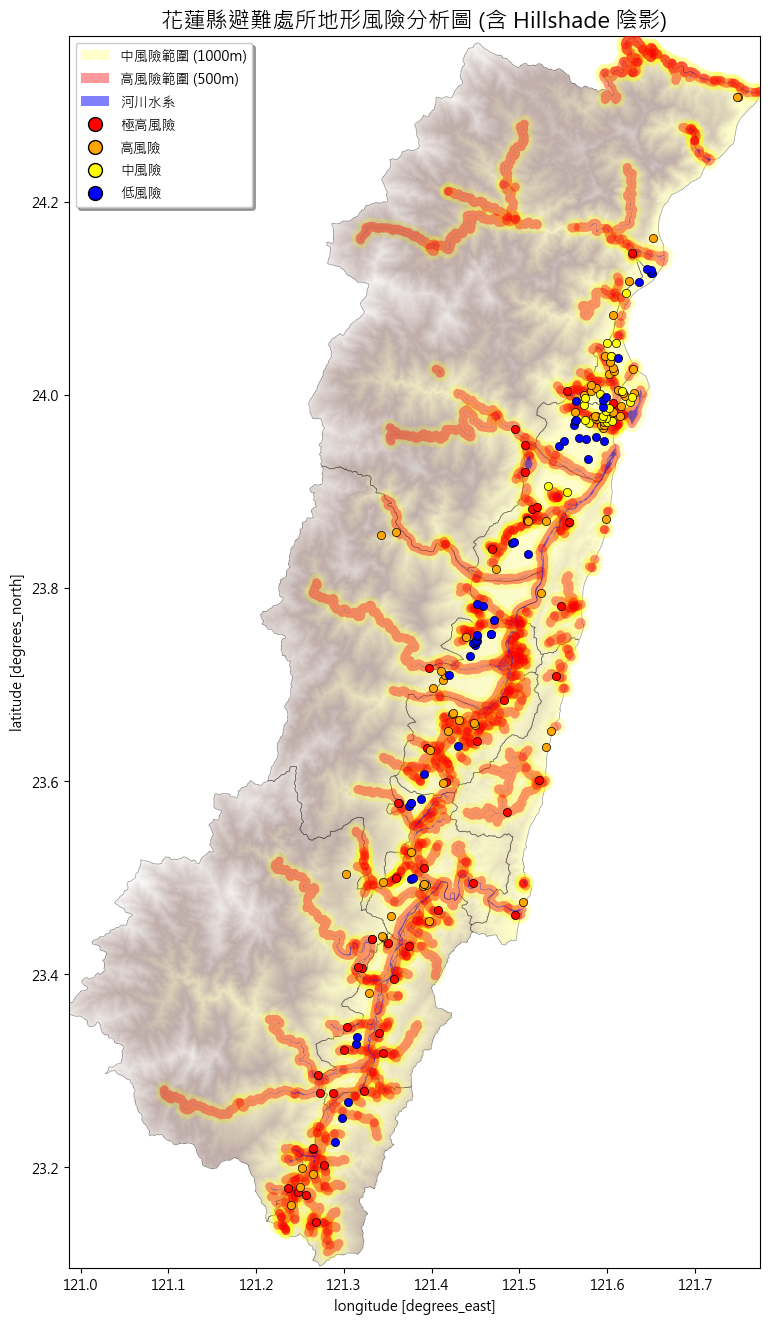

In [15]:
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
import geopandas as gpd
import numpy as np
from matplotlib.colors import LightSource  # 新增：用於產生陰影效果

# --- 1. 字體與環境設定 ---
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False

# --- 2. 圖層轉換 (WGS84) ---
bh_4326 = gpd.GeoDataFrame(geometry=buffer_high_geom, crs='EPSG:3826').to_crs(epsg=4326)
bm_4326 = gpd.GeoDataFrame(geometry=buffer_med_geom, crs='EPSG:3826').to_crs(epsg=4326)
t_4326 = hualien_towns.to_crs(epsg=4326)
r_4326 = hualien_rivers.to_crs(epsg=4326)
s_4326 = hualien_shelters.to_crs(epsg=4326)

# --- 3. 準備繪圖 ---
fig, ax = plt.subplots(figsize=(12, 16))

# 設定座標範圍
b = t_4326.total_bounds
ax.set_xlim(b[0], b[2])
ax.set_ylim(b[1], b[3])

# --- 4. 疊合 DEM + Hillshade ---
try:
    # A. 座標轉換
    dem_4326 = dem.rio.reproject("EPSG:4326", resampling=Resampling.bilinear)
    
    # B. 準備數值 (取出 2D Array 並處理空值)
    elevation = dem_4326.values.squeeze()
    elevation = np.nan_to_num(elevation, nan=0) # 將 NaN 轉為 0 避免計算錯誤
    
    # C. 建立光源 (azdeg=光源方位角, altdeg=光源高度角)
    ls = LightSource(azdeg=315, altdeg=45)
    
    # D. 計算 Hillshade (陰影)
    # vert_exag 用於調整垂直誇大比例，若地形太扁平可以調高 (例如 2)
    hillshade = ls.hillshade(elevation, vert_exag=1)
    
    # E. 繪製圖層
    # 先畫 Hillshade (底層，黑白)
    ax.imshow(hillshade, extent=dem_4326.rio.bounds(), cmap='gray', origin='upper', zorder=0)
    
    # 再畫彩色 DEM (疊在陰影上，透過 alpha 顯示出立體感)
    dem_4326.plot(ax=ax, cmap='terrain', alpha=0.5, zorder=0, add_colorbar=False)
    
except Exception as e:
    print(f"DEM/Hillshade 底圖載入失敗: {e}")

# --- 5. 繪製其他向量圖層 ---
t_4326.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5, alpha=0.4, zorder=1) # 行政區
bm_4326.plot(ax=ax, color='yellow', alpha=0.2, zorder=2) # 1000m 緩衝
bh_4326.plot(ax=ax, color='red', alpha=0.4, zorder=3)    # 500m 緩衝
r_4326.plot(ax=ax, color='blue', linewidth=0.8, alpha=0.5, zorder=4) # 河川

# 避難所
risk_colors = {'極高風險': 'red', '高風險': 'orange', '中風險': 'yellow', '低風險': 'blue'}
for level, color in risk_colors.items():
    subset = s_4326[s_4326['risk_level'] == level]
    if not subset.empty:
        subset.plot(ax=ax, color=color, markersize=35, edgecolor='black', linewidth=0.5, label=level, zorder=10)

# --- 6. 圖例與標註 ---
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='yellow', alpha=0.2, label='中風險範圍 (1000m)'),
    Patch(facecolor='red', alpha=0.4, label='高風險範圍 (500m)'),
    Patch(facecolor='blue', alpha=0.5, label='河川水系'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='black', markersize=10, label='極高風險'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markeredgecolor='black', markersize=10, label='高風險'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markeredgecolor='black', markersize=10, label='中風險'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markeredgecolor='black', markersize=10, label='低風險')
]

ax.set_aspect(1.1)
plt.title("花蓮縣避難處所地形風險分析圖 (含 Hillshade 陰影)", fontsize=16)
plt.legend(handles=legend_elements, loc='upper left', shadow=True)

# 儲存
save_path = '../outputs/terrain_risk_map.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"圖片已儲存至: {save_path}")

plt.show()

# 繪製Top 10 高風險避難所的坡度 vs. 高程散佈圖

統計圖已儲存至: ../outputs/top10_risk_scatter.png


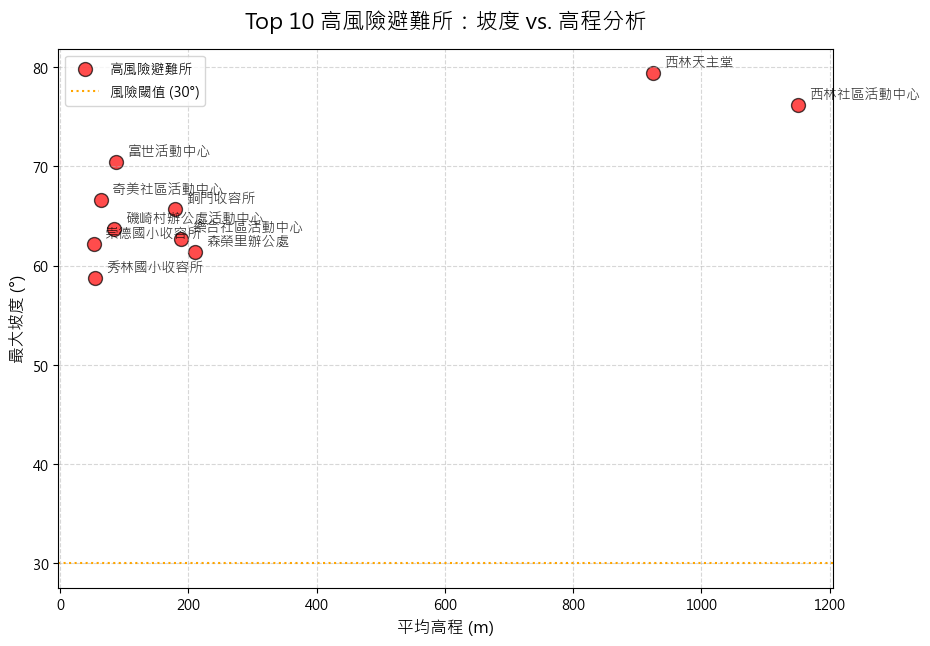

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 設定中文字體 (微軟正黑體)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 篩選資料：取得前 10 名高風險避難所 (假設以最大坡度排序)
# 如果你有極高風險，建議先篩選極高風險
top_10 = hualien_shelters[hualien_shelters['risk_level'].isin(['極高風險', '高風險'])] \
            .sort_values(by='max_slope', ascending=False) \
            .head(10)

# 3. 建立畫布
plt.figure(figsize=(10, 7))

# 4. 繪製散佈圖
# X軸：平均高程, Y軸：最大坡度
plt.scatter(top_10['mean_elevation'], top_10['max_slope'], 
            c='red', s=100, alpha=0.7, edgecolors='black', label='高風險避難所')

# 5. 為每個點加上名稱標籤 (文字標註)
for i, row in top_10.iterrows():
    plt.annotate(row['避難收容處所名稱'], 
                 (row['mean_elevation'], row['max_slope']),
                 xytext=(8, 5),             # 文字偏移位置
                 textcoords='offset points', 
                 fontsize=10,
                 alpha=0.8)

# 6. 設定圖表裝飾
plt.title('Top 10 高風險避難所：坡度 vs. 高程分析', fontsize=16, pad=15)
plt.xlabel('平均高程 (m)', fontsize=12)
plt.ylabel('最大坡度 (°)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 加入一條坡度 30 度的警戒線
plt.axhline(y=30, color='orange', linestyle=':', label='風險閾值 (30°)')

plt.legend()

# 7. 儲存圖片
save_path = '../outputs/top10_risk_scatter.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"統計圖已儲存至: {save_path}")

plt.show()